In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
# Read the data
ames = pd.read_csv("AmesHousing.csv")

# Get rid of columns with mostly NaN values
good_cols = ames.isna().sum() < 100
ames = ames.loc[:,good_cols]

# Drop other NAs
ames = ames.dropna()

In [3]:
X = ames.drop(["SalePrice", "Order", "PID"], axis = 1)
y = ames["SalePrice"]


ct = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False, handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

lr_pipeline = Pipeline(
  [("preprocessing", ct),
  ("linear_regression", LinearRegression())]
)

cross_val_score(lr_pipeline, X, y, cv = 5, scoring = 'r2')

array([-1.00227561e+21, -2.13473460e+19, -4.65481157e+21, -4.24892786e+21, -4.16001805e+22])

In [4]:
lr_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x157d93f80>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x157d93260>)])),
                ('linear_regression', LinearRegression())])

In [5]:
ols_coefficents = lr_pipeline.named_steps["linear_regression"].coef_
ols_coefficents

array([ 5.22832476e+16,  5.22832476e+16,  5.22832476e+16,  5.22832476e+16,  5.22832476e+16,  5.22832476e+16,  7.31784517e+16,  7.31784517e+16,
        1.27758001e+17,  1.27758001e+17,  1.27758001e+17,  1.27758001e+17, -1.09897667e+17, -1.09897667e+17, -1.09897667e+17, -1.09897667e+17,
       -5.35118184e+15, -5.35118184e+15, -5.35118184e+15,  5.62430416e+16,  5.62430416e+16,  5.62430416e+16,  5.62430416e+16,  5.62430416e+16,
       -1.14509554e+16, -1.14509554e+16, -1.14509554e+16, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17,
       -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17,
       -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17,
       -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.19515150e+17, -1.92034325e+16,

In [1]:
X = ames.drop(["SalePrice", "Order", "PID"], axis = 1)
y = ames["SalePrice"]

ct = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False, handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

ridge_pipeline = Pipeline(
  [("preprocessing", ct),
  ("ridge", Ridge(alpha = 1))]
)

cross_val_score(ridge_pipeline, X, y, cv = 5, scoring = 'r2')

NameError: name 'ames' is not defined

In [7]:
alphas = {'ridge__alpha': [0.001,0.01,0.1,1,10]}

gscv = GridSearchCV(ridge_pipeline, alphas, cv = 5, scoring='r2')

In [8]:
gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

{'mean_fit_time': array([0.03918695, 0.0490118 , 0.06046181, 0.06802077, 0.05308576]),
 'std_fit_time': array([0.00503426, 0.01078988, 0.01496868, 0.01582698, 0.0073313 ]),
 'mean_score_time': array([0.01399946, 0.01568484, 0.01975713, 0.02071929, 0.01684818]),
 'std_score_time': array([0.00433184, 0.00293952, 0.00377094, 0.00834325, 0.00193466]),
 'param_ridge__alpha': masked_array(data=[0.001, 0.01, 0.1, 1, 10],
              mask=[False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'ridge__alpha': 0.001},
  {'ridge__alpha': 0.01},
  {'ridge__alpha': 0.1},
  {'ridge__alpha': 1},
  {'ridge__alpha': 10}],
 'split0_test_score': array([0.8972854 , 0.89734306, 0.89774358, 0.89815807, 0.8977621 ]),
 'split1_test_score': array([0.91040618, 0.91061417, 0.91230557, 0.91744024, 0.92081211]),
 'split2_test_score': array([0.78901601, 0.7891259 , 0.79010977, 0.79493606, 0.80057243]),
 'split3_test_score': array([0.7721318 , 0.77253192, 0.77576412, 

In [9]:
gscv_fitted.cv_results_['mean_test_score']

array([0.85392021, 0.85418638, 0.85630206, 0.86193163, 0.86427221])

In [10]:
pd.DataFrame(data = {"alphas": [0.001, 0.01, 0.1, 1, 10], "scores": gscv_fitted.cv_results_['mean_test_score']})

,alphas,scores
0,0.001,0.853920
1,0.010,0.854186
2,0.100,0.856302
3,1.000,0.861932
4,10.000,0.864272


In [11]:
ridge_pipeline.fit(X, y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x157d8cf50>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x157d8ea20>)])),
                ('ridge', Ridge(alpha=1))])

In [12]:
ridge_coefficents = ridge_pipeline.named_steps["ridge"].coef_
ridge_coefficents


array([-5.58514707e+03,  1.27959973e+03, -5.46571776e+03,  7.87614164e+03,  3.04609538e+03, -1.15097192e+03, -9.33396395e+03,  9.33396395e+03,
        1.22549207e+03,  7.29888520e+03, -1.08647168e+04,  2.34033949e+03, -8.75436678e+03,  9.01003491e+03, -3.97712861e+03,  3.72146049e+03,
        9.41980874e+03, -8.79255885e+03, -6.27249885e+02,  8.17535896e+02,  8.01641445e+03, -5.69763865e+03, -3.98756032e+03,  8.51248627e+02,
        8.79698364e+02,  7.61644748e+03, -8.49614584e+03, -3.15970613e+03,  4.27236551e+03,  7.88847839e+03, -5.86113592e+03, -9.15806934e+03,
       -1.14550380e+04,  6.03134279e+03, -2.05039767e+04, -1.35486631e+04,  5.21751589e+03,  6.65306858e+04, -1.21001139e+04, -2.25857464e+03,
        8.65313918e+02, -1.52143284e+04, -1.58503469e+04,  9.55308503e+03, -1.82636881e+04,  2.78380350e+04,  2.24166992e+04, -1.59147424e+04,
       -1.30475803e+04, -1.14575200e+04, -1.24710470e+04,  1.07458866e+04,  3.69996740e+04, -8.28754419e+03, -9.80700715e+03, -2.58169293e+03,

In [13]:
X = ames.drop(["SalePrice", "Order", "PID"], axis = 1)
y = ames["SalePrice"]


ct = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False, handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

lasso_pipeline = Pipeline(
  [("preprocessing", ct),
  ("lasso", Lasso(alpha = 1))]
)

cross_val_score(lasso_pipeline, X, y, cv = 5, scoring = 'r2')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.323e+10, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


array([0.89774385, 0.91093785, 0.79691806, 0.77426245, 0.90589888])

In [14]:
alphas = {'lasso__alpha': [0.001,0.01,0.1,1,10]}

gscv = GridSearchCV(lasso_pipeline, alphas, cv = 5, scoring='r2')

gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.109e+11, tolerance: 1.348e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.466e+11, tolerance: 1.474e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.894e+11, tolerance: 1.463e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.756e+11, tolerance: 1.407e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.569e+11, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.588e+11, tolerance: 1.463e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.698e+11, tolerance: 1.407e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.557e+11, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.323e+10, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


{'mean_fit_time': array([1.57969837, 1.87584567, 1.74486418, 1.50985532, 0.338873  ]),
 'std_fit_time': array([0.30702686, 0.26028048, 0.46695742, 0.20058649, 0.17265138]),
 'mean_score_time': array([0.01987157, 0.06412044, 0.01854324, 0.022576  , 0.01384463]),
 'std_score_time': array([0.00301726, 0.08952167, 0.00284108, 0.0034486 , 0.00239836]),
 'param_lasso__alpha': masked_array(data=[0.001, 0.01, 0.1, 1, 10],
              mask=[False, False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'lasso__alpha': 0.001},
  {'lasso__alpha': 0.01},
  {'lasso__alpha': 0.1},
  {'lasso__alpha': 1},
  {'lasso__alpha': 10}],
 'split0_test_score': array([0.8972019 , 0.89720561, 0.89725821, 0.89774385, 0.90077569]),
 'split1_test_score': array([0.9103958 , 0.91040134, 0.91045103, 0.91093785, 0.91506699]),
 'split2_test_score': array([0.79032004, 0.79085941, 0.79595065, 0.79691806, 0.80141962]),
 'split3_test_score': array([0.77402031, 0.77406031, 0.77407171, 

In [15]:
gscv_fitted.cv_results_['mean_test_score']

array([0.85549892, 0.85560578, 0.85661828, 0.85715222, 0.86063224])

In [16]:
pd.DataFrame(data = {"alphas": [0.001, 0.01, 0.1, 1, 10], "scores": gscv_fitted.cv_results_['mean_test_score']})

,alphas,scores
0,0.001,0.855499
1,0.010,0.855606
2,0.100,0.856618
3,1.000,0.857152
4,10.000,0.860632


In [18]:
lasso_pipeline.fit(X,y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x16809f6e0>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x17fca02c0>)])),
                ('lasso', Lasso(alpha=1))])

In [19]:
lasso_coefficents = lasso_pipeline.named_steps["lasso"].coef_
lasso_coefficents

array([-4.81652839e+03,  1.22724439e+03, -4.41885541e+03,  7.51982576e+03,  3.53293929e+03, -1.15175663e+03, -2.04473222e+04,  3.67205820e-09,
       -1.41031927e+03,  4.70209827e+03,  4.83124102e+02, -1.26904092e+01, -9.03194952e+03,  5.48345937e+03, -1.09548228e+04,  1.19715987e+02,
        1.48059948e+04, -2.46716222e+03,  0.00000000e+00,  2.89970113e+02,  6.47083982e+03, -6.06559741e+03, -4.80860054e+03, -0.00000000e+00,
       -0.00000000e+00,  6.66914878e+03, -1.63491350e+04,  3.88720104e+03,  1.02876243e+04,  1.35648346e+04,  1.05643345e+03, -4.16387582e+03,
       -6.38723226e+03,  1.16048567e+04, -1.37388021e+04, -7.33924495e+03,  1.20934300e+04,  1.32015734e+05, -5.39197495e+03,  0.00000000e+00,
        7.56702466e+03, -1.01640833e+04, -1.01751839e+04,  1.84286710e+04, -1.33019305e+04,  3.10914289e+04,  2.52024813e+04, -9.36511398e+03,
       -7.37390650e+03, -5.84233241e+03, -7.33009072e+03,  1.60093014e+04,  4.27819615e+04, -4.11202868e+03, -7.19672101e+03, -2.09327946e+03,

In [21]:
X = ames.drop(["SalePrice", "Order", "PID"], axis = 1)
y = ames["SalePrice"]


ct = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False, handle_unknown='ignore'), make_column_selector(dtype_include=object)),
    ("standardize", StandardScaler(), make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

elastic_net_pipeline = Pipeline(
  [("preprocessing", ct),
  ("elastic_net", ElasticNet(alpha = 1, l1_ratio = 0.5))]
)

cross_val_score(elastic_net_pipeline, X, y, cv = 5, scoring = 'r2')

array([0.84843362, 0.89484602, 0.78295991, 0.74618167, 0.88108029])

In [22]:
param_grid = {
    'elastic_net__alpha': [0.001,0.01,0.1,1,10],
    'elastic_net__l1_ratio': [0.10,0.25,0.5,0.75,0.90]}

gscv = GridSearchCV(elastic_net_pipeline, param_grid, cv = 5, scoring='r2')

gscv_fitted = gscv.fit(X, y)

gscv_fitted.cv_results_

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.466e+11, tolerance: 1.348e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.259e+11, tolerance: 1.474e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.122e+11, tolerance: 1.463e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.353e+11, tolerance: 1.407e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.237e+11, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


...

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.103e+11, tolerance: 1.463e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.356e+11, tolerance: 1.407e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.233e+11, tolerance: 1.477e+09
  model = cd_fast.enet_coordinate_descent(


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.064e+09, tolerance: 1.793e+09
  model = cd_fast.enet_coordinate_descent(


{'mean_fit_time': array([1.9644444 , 1.44198761, 1.58922668, 1.69937997, 1.42430439, 1.10923219, 0.93047657, 1.20817556, 1.14739132, 1.11606097, 0.1608047 ,
        0.15781379, 0.20152822, 0.27306299, 0.5300652 , 0.07441039, 0.08196259, 0.09318476, 0.10745745, 0.13204484, 0.04171276, 0.04406981,
        0.04576259, 0.04887228, 0.05379848]),
 'std_fit_time': array([1.12239797, 0.27164025, 0.17384779, 0.04693606, 0.11453662, 0.15107001, 0.09075022, 0.08336086, 0.07985804, 0.11660931, 0.00728502,
        0.00300862, 0.03434427, 0.04493063, 0.06450402, 0.00595701, 0.00994897, 0.00847287, 0.008877  , 0.00630526, 0.00474837, 0.00153414,
        0.00614297, 0.00559517, 0.00265617]),
 'mean_score_time': array([0.02426186, 0.01650143, 0.01937933, 0.0189528 , 0.01781249, 0.01708469, 0.01745501, 0.01648941, 0.01763515, 0.01515999, 0.01306033,
        0.01078715, 0.01347342, 0.01098256, 0.01317925, 0.01216683, 0.01682081, 0.01555047, 0.01329384, 0.01580076, 0.01222887, 0.01150537,
        0.010595

In [23]:
gscv_fitted.cv_results_['mean_test_score']

array([0.86306078, 0.86281308, 0.86215515, 0.86064079, 0.85818692, 0.86384771, 0.86405936, 0.86426789, 0.86405067, 0.86319427, 0.8525391 ,
       0.85403034, 0.85698683, 0.86088123, 0.86368729, 0.81571562, 0.82116844, 0.8307003 , 0.84185231, 0.85161277, 0.55986393, 0.59867086,
       0.67323913, 0.75882319, 0.8119943 ])

In [24]:
degrees = pd.DataFrame(gscv_fitted.cv_results_["params"])
results = degrees.assign(scores=gscv_fitted.cv_results_['mean_test_score'])
results.sort_values(by='scores', ascending=False)

,elastic_net__alpha,elastic_net__l1_ratio,scores
7,0.010,0.50,0.864268
6,0.010,0.25,0.864059
8,0.010,0.75,0.864051
5,0.010,0.10,0.863848
14,0.100,0.90,0.863687
9,0.010,0.90,0.863194
0,0.001,0.10,0.863061
1,0.001,0.25,0.862813
2,0.001,0.50,0.862155
13,0.100,0.75,0.860881


In [25]:
elastic_net_pipeline.fit(X,y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('dummify',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x17cdeddc0>),
                                                 ('standardize',
                                                  StandardScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x17cded7c0>)])),
                ('elastic_net', ElasticNet(alpha=1))])

In [26]:
elastic_net_coefficents = elastic_net_pipeline.named_steps["elastic_net"].coef_
elastic_net_coefficents

array([-1.41971922e+02,  3.49433582e+02, -2.03580414e+01, -5.50851860e+01,  1.19278794e+03, -1.32280672e+03, -1.62088197e+02,  1.62088197e+02,
        1.20556585e+03,  4.53852497e+02, -3.23910163e+02, -1.33550888e+03, -1.01959675e+03,  1.78364939e+03,  3.73732791e+01, -8.01425975e+02,
        6.48076760e+01, -3.10352740e+01, -3.27724020e+01, -4.64171474e+02,  1.06965273e+03, -3.89430628e+02, -4.94795451e+01, -1.63571034e+02,
       -7.68560979e+02,  8.11751119e+02, -4.21901543e+01, -2.80646693e+02, -1.70414981e+01, -2.17215254e+02,  2.65237116e+02,  2.72005729e+01,
       -1.07250023e+03,  1.18511274e+03, -1.16462268e+03, -9.82172859e+02,  2.14559216e+01,  8.67592166e+01, -2.20022688e+02, -9.47995459e+00,
       -7.26218253e+01, -4.68320312e+02, -1.08213199e+03, -2.92015469e+01, -1.03046500e+03,  1.58235398e+03,  3.10851930e+03, -7.59182036e+02,
       -1.49004190e+02, -2.52738636e+02, -6.97839903e+02,  5.19177028e+02,  1.64043545e+03, -1.24196749e+01,  8.93755209e+01, -4.40605345e+02,

In [34]:
coeff_df = pd.DataFrame({
    "Linear": ols_coefficents,
    "Ridge": ridge_coefficents,
    "Lasso": lasso_coefficents,
    "Elastic": elastic_net_coefficents
}).melt(var_name="Model", value_name="Coefficient")


In [35]:
coeff_df

,Model,Coefficient
0,Linear,5.228325e+16
1,Linear,5.228325e+16
2,Linear,5.228325e+16
3,Linear,5.228325e+16
4,Linear,5.228325e+16
...,...,...
1011,Elastic,2.597363e+03
1012,Elastic,9.968853e+01
1013,Elastic,-3.157505e+03
1014,Elastic,-7.813778e+01


In [39]:
from plotnine import *

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
/opt/anaconda3/lib/python3.12/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 549 rows containing non-finite values.


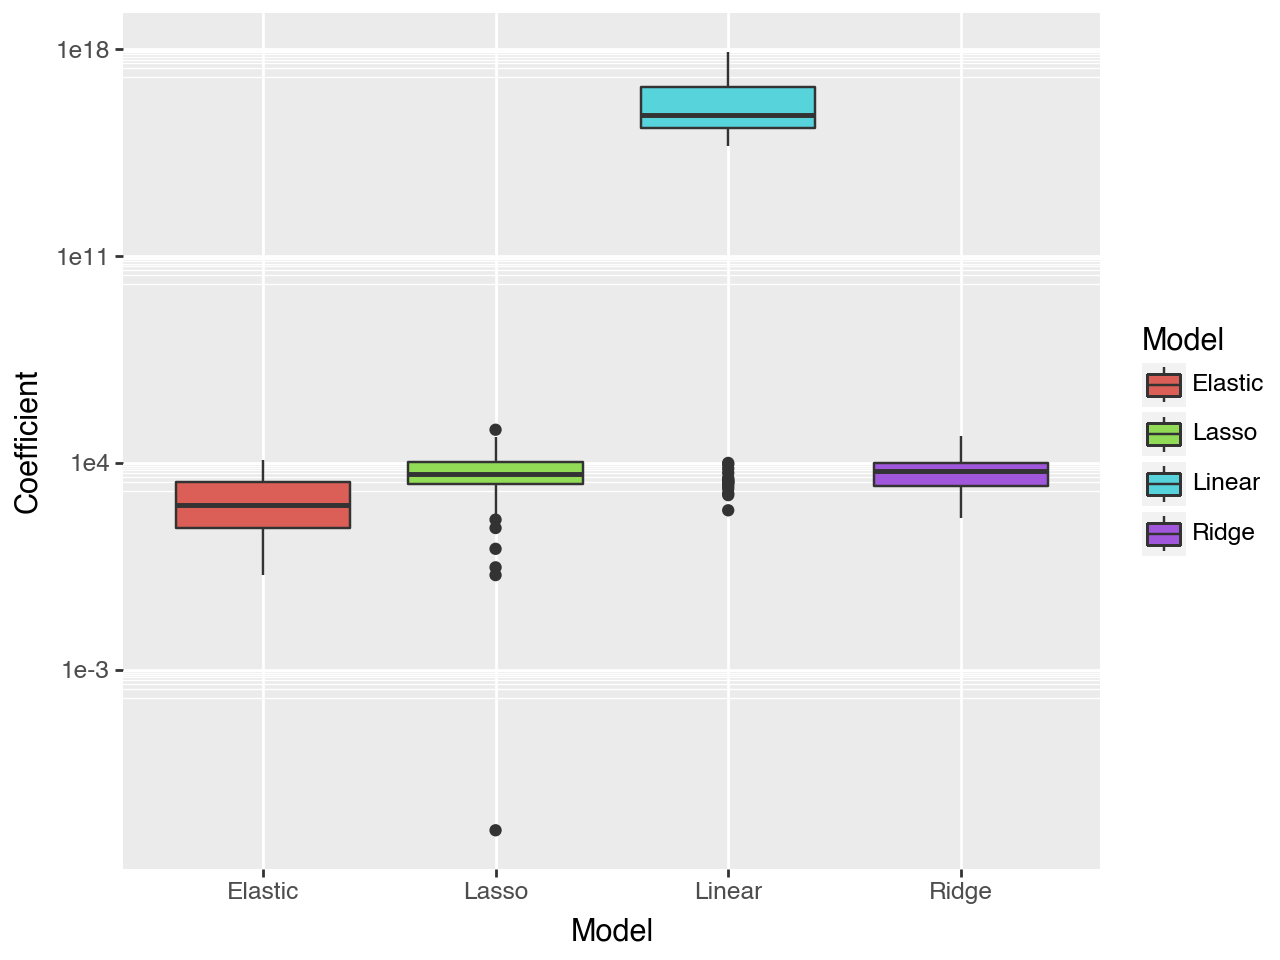

In [41]:
(ggplot(coeff_df,
aes (x="Model", y="Coefficient", fill="Model"))
+ geom_boxplot()
+ scale_y_log10())